In [1]:
!pip install pandasql


  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=d0affcfe9241d0ef5c24e0b6ab5d2aeaba6e9815f72b80ff90f087a740df92a6
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [2]:
import numpy as np
import pandas as pd
import spacy
import nltk
import re
import json
from nltk.corpus import stopwords
import pandas as pd
from pandasql import sqldf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report

Reading Data and Initial Exploration

In [4]:
import pandas as pd

df = pd.read_csv("r_dataisbeautiful_posts.csv")

print("The data shape is:", df.shape)
df.head(10)

The data shape is: (190853, 12)


/tmp/ipykernel_13484/3600559364.py:3: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("r_dataisbeautiful_posts.csv")


,id,title,score,author,author_flair_text,removed_by,total_awards_received,awarders,created_utc,full_link,num_comments,over_18
0,ll1p9h,Wordcloud of trending video titles on YouTube ...,1,OmarZiada,OC: 1,NaN,0.0,[],1613473961,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
1,ll1o4h,Wordcloud of trending videos on YouTube in the...,1,OmarZiada,OC: 1,moderator,0.0,[],1613473829,https://www.reddit.com/r/dataisbeautiful/comme...,1,False
2,ll15gx,Immunization in India. Source: https://niti.go...,1,Professional_Napper_,NaN,moderator,0.0,[],1613471541,https://www.reddit.com/r/dataisbeautiful/comme...,1,False
3,ll0iup,How to quickly estimate the impact of players ...,1,Viziball,NaN,automod_filtered,0.0,[],1613468624,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
4,ll0g9a,How to quickly estimate the impact of players ...,1,Viziball,NaN,moderator,0.0,[],1613468281,https://www.reddit.com/r/dataisbeautiful/comme...,2,False
5,ll0ak6,PhpStorm 2020.3.3 Crack Full Activation Code L...,1,maxpoul,NaN,reddit,0.0,[],1613467496,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
6,ll09om,3DMark 2.17.7137 Crack + Serial Key 2021 For [...,1,maxpoul,NaN,reddit,0.0,[],1613467373,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
7,ll07x2,DaVinci Resolve Studio 17.0 Cracked Patch Lice...,1,maxpoul,NaN,reddit,0.0,[],1613467141,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
8,ll06wq,Auslogics File Recovery 10 Crack + License Key...,1,maxpoul,NaN,reddit,0.0,[],1613467004,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
9,lkz1wm,[OC] Timeline of the Rise and Fall of $GME (st...,1,holospiritwolf,NaN,NaN,0.0,[],1613461981,https://www.reddit.com/r/dataisbeautiful/comme...,9,False


In [5]:
df.describe()

,score,total_awards_received,created_utc,num_comments
count,190853.000000,65146.000000,1.908530e+05,190853.000000
mean,176.016159,0.013109,1.512494e+09,27.604732
std,1951.936524,0.589425,6.822624e+07,213.236378
min,0.000000,0.000000,1.329263e+09,0.000000
25%,1.000000,0.000000,1.463862e+09,1.000000
50%,1.000000,0.000000,1.518662e+09,2.000000
75%,4.000000,0.000000,1.576576e+09,5.000000
max,116226.000000,93.000000,1.613474e+09,18801.000000


In [6]:
df.isnull().sum()

,0
id,0
title,1
score,0
author,0
author_flair_text,162008
removed_by,170109
total_awards_received,125707
awarders,136375
created_utc,0
full_link,0


In [7]:
pysqldf = lambda q: sqldf(q, globals())

In [8]:
# Just Reading the data using psql
q1 = "SELECT * FROM df LIMIT 10;"
pysqldf(q1)

,id,title,score,author,author_flair_text,removed_by,total_awards_received,awarders,created_utc,full_link,num_comments,over_18
0,ll1p9h,Wordcloud of trending video titles on YouTube ...,1,OmarZiada,OC: 1,None,0.0,[],1613473961,https://www.reddit.com/r/dataisbeautiful/comme...,0,0
1,ll1o4h,Wordcloud of trending videos on YouTube in the...,1,OmarZiada,OC: 1,moderator,0.0,[],1613473829,https://www.reddit.com/r/dataisbeautiful/comme...,1,0
2,ll15gx,Immunization in India. Source: https://niti.go...,1,Professional_Napper_,None,moderator,0.0,[],1613471541,https://www.reddit.com/r/dataisbeautiful/comme...,1,0
3,ll0iup,How to quickly estimate the impact of players ...,1,Viziball,None,automod_filtered,0.0,[],1613468624,https://www.reddit.com/r/dataisbeautiful/comme...,0,0
4,ll0g9a,How to quickly estimate the impact of players ...,1,Viziball,None,moderator,0.0,[],1613468281,https://www.reddit.com/r/dataisbeautiful/comme...,2,0
5,ll0ak6,PhpStorm 2020.3.3 Crack Full Activation Code L...,1,maxpoul,None,reddit,0.0,[],1613467496,https://www.reddit.com/r/dataisbeautiful/comme...,0,0
6,ll09om,3DMark 2.17.7137 Crack + Serial Key 2021 For [...,1,maxpoul,None,reddit,0.0,[],1613467373,https://www.reddit.com/r/dataisbeautiful/comme...,0,0
7,ll07x2,DaVinci Resolve Studio 17.0 Cracked Patch Lice...,1,maxpoul,None,reddit,0.0,[],1613467141,https://www.reddit.com/r/dataisbeautiful/comme...,0,0
8,ll06wq,Auslogics File Recovery 10 Crack + License Key...,1,maxpoul,None,reddit,0.0,[],1613467004,https://www.reddit.com/r/dataisbeautiful/comme...,0,0
9,lkz1wm,[OC] Timeline of the Rise and Fall of $GME (st...,1,holospiritwolf,None,None,0.0,[],1613461981,https://www.reddit.com/r/dataisbeautiful/comme...,9,0


In [9]:
#Count of Posts per author
q2 = """
SELECT author, COUNT(*) AS total_posts
FROM df
GROUP BY author
ORDER BY total_posts DESC;
"""
pysqldf(q2)

,author,total_posts
0,[deleted],26849
1,jimrosenz,1744
2,OverflowDs,446
3,caobanlong,314
4,pdwp90,300
...,...,...
82731,--Julius,1
82732,---sniff---,1
82733,---andrew,1
82734,---_-___,1


In [10]:
#Average score per author flair
q3 = """
SELECT author_flair_text, AVG(score) AS avg_score, COUNT(*) AS num_posts
FROM df
WHERE author_flair_text IS NOT NULL
GROUP BY author_flair_text
ORDER BY avg_score DESC;
"""
pysqldf(q3)

,author_flair_text,avg_score,num_posts
0,OC: 137,18653.000000,3
1,OC: 86,8750.000000,9
2,OC: 82,8322.200000,10
3,OC: 85,5432.555556,9
4,OC: 76,5006.125000,8
...,...,...,...
194,OC: 115,1.000000,4
195,OC: 112,1.000000,2
196,OC: 105,1.000000,2
197,Martín González and Evan Henſleigh,1.000000,1


In [11]:
# Posts with above-average score (CTE example)
q4 = """
WITH avg_score_cte AS (
    SELECT AVG(score) AS avg_score FROM df
)
SELECT id, title, author, score
FROM df, avg_score_cte
WHERE score > avg_score_cte.avg_score
ORDER BY score DESC;
"""
pysqldf(q4)

,id,title,author,score
0,7elwve,Imagine having to pay money to share your data...,MOSTEPICPLAYER,116226
1,b5f9wi,Let's hear it for the lurkers! The vast majori...,TrueBirch,105255
2,8cwcbu,Cause of Death - Reality vs. Google vs. Media ...,aaronpenne,101451
3,8bzdr8,Gaze and foot placement when walking over roug...,sandusky_hohoho,99611
4,dbntq8,"Light Speed – fast, but slow [OC]",physicsJ,92686
...,...,...,...,...
6642,1v1pdu,OKCupid average match rate by zodiac sign (60 ...,Vortigern,177
6643,1pz3ad,"Winning Consistency among MLB, NBA, and NFL Te...",Vizual-Statistix,177
6644,1jeo65,Periodic Table of Elements represented by atom...,Naznarreb,177
6645,z3vyc,Wolfram|Alpha Personal Analytics for Facebook,mkhry,177


In [12]:
#Distribution of NSFW (over_18) posts

q5 = """
SELECT over_18, COUNT(*) AS post_count,
       ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM df), 2) AS percent FROM df GROUP BY over_18;
"""
pysqldf(q5)

,over_18,post_count,percent
0,0,189785,99.44
1,1,1068,0.56


In [13]:
# Total posts removed + percentage by moderator
q6a = """
WITH total_posts AS (
    SELECT COUNT(*) AS total_count FROM df
),
removed_summary AS (
    SELECT
        removed_by,
        COUNT(*) AS total_removed
    FROM df
    WHERE removed_by IS NOT NULL
    GROUP BY removed_by
)
SELECT
    r.removed_by,
    r.total_removed,
    ROUND(100.0 * r.total_removed / t.total_count, 2) AS percent_removed
FROM removed_summary r, total_posts t
ORDER BY percent_removed DESC;
"""
pysqldf(q6a)

,removed_by,total_removed,percent_removed
0,moderator,14789,7.75
1,deleted,2948,1.54
2,automod_filtered,1553,0.81
3,reddit,1453,0.76
4,author,1,0.00


In [14]:
#NSFW vs SFW deletion distribution
q6b = """
WITH deletion_stats AS (
    SELECT
        over_18,
        CASE WHEN removed_by IS NOT NULL THEN 'Deleted' ELSE 'Not Deleted' END AS deletion_status,
        COUNT(*) AS post_count
    FROM df
    GROUP BY over_18, deletion_status
),
total_counts AS (
    SELECT SUM(post_count) AS total_posts FROM deletion_stats
)
SELECT
    d.over_18,
    d.deletion_status,
    d.post_count,
    ROUND(100.0 * d.post_count / t.total_posts, 2) AS percent_of_total
FROM deletion_stats d, total_counts t
ORDER BY d.over_18, d.deletion_status;
"""
pysqldf(q6b)

,over_18,deletion_status,post_count,percent_of_total
0,0,Deleted,20585,10.79
1,0,Not Deleted,169200,88.65
2,1,Deleted,159,0.08
3,1,Not Deleted,909,0.48


In [15]:
#Top posts by number of comments (Window function)
q7 = """
SELECT id, title, author, num_comments,
       RANK() OVER (ORDER BY num_comments DESC) AS comment_rank
FROM df
ORDER BY num_comments DESC
LIMIT 10;
"""
pysqldf(q7)

,id,title,author,num_comments,comment_rank
0,62nk25,data_irl,mungoflago,18801,1
1,huk3pp,The best (&amp; worst) countries for raising a...,asherfergusson,12508,2
2,7swce8,Police killing rates in G7 members [OC],Udzu,10425,3
3,hwlxld,[oc] How taboo and popular are sexual fetishes...,AellaGirl,10396,4
4,fqqzki,Worst Episode Ever? The Most Commonly Rated Sh...,BoMcCready,9217,5
5,i2vx78,The environmental impact of Beyond Meat and a ...,blackphantom773,9120,6
6,5zpol9,What's getting cut in Trump's budget,Prince-Akeem,8768,7
7,hvyobp,"[OC] Mississippi, the Poorest State in the US",JoeFalchetto,8703,8
8,jsug9l,[OC] Trump voters are less likely to have a co...,heresacorrection,8354,9
9,hs9mnz,[OC] Trending Google Searches by State Between...,V1Analytics,8270,10


In [16]:
#Award insights
q9 = """
SELECT author, SUM(total_awards_received) AS total_awards,
       AVG(total_awards_received) AS avg_awards
FROM df
GROUP BY author
HAVING total_awards > 0
ORDER BY total_awards DESC;
"""
pysqldf(q9)

,author,total_awards,avg_awards
0,chartr,93.0,1.056818
1,already-taken-wtf,55.0,9.166667
2,getToTheChopin,54.0,7.714286
3,Master4pprentice,40.0,8.000000
4,whereAreTheShares,35.0,11.666667
...,...,...,...
173,BiggTiff,1.0,1.000000
174,Alexander_Varlamov,1.0,0.125000
175,Abram_SF,1.0,0.333333
176,ADarkcid,1.0,1.000000


In [17]:
#CTE + Window Function combined: Top 3 posts per author
q10 = """
WITH ranked_posts AS (
    SELECT author, id, title, score,
           ROW_NUMBER() OVER (PARTITION BY author ORDER BY score DESC) AS rn
    FROM df
)
SELECT * FROM ranked_posts WHERE rn <= 3;
"""
pysqldf(q10)

,author,id,title,score,rn
0,-----iMartijn-----,7165a7,The price of bitcoin has a 91% correlation wit...,45,1
1,-----iMartijn-----,5um0cv,Americans double standard on religious violence,5,2
2,----Aaron----,9sxdjp,What if each Waitrose and Lidl store in London...,1,1
3,----Aaron----,9sxba3,Tube map of all the branches of Waitrose and L...,1,2
4,----Aaron----,9sx8gu,What if each Waitrose and Lidl store in London...,1,3
...,...,...,...,...,...
119025,zzzxsderfgt,5oym39,Solutions Number @@1-800-799-2667@@ Dell Print...,1,1
119026,zzzyx3,7i7t06,I need statistical data for my math final! Pls...,1,1
119027,zzzzz94,5mtfxz,"Inflation vs. Wage Growth, 1960-2015",30,1
119028,zzzzz94,5n0zhs,"Wage Growth vs. Inflation, 1960-2015",3,2


In [18]:
df.isnull().sum()

,0
id,0
title,1
score,0
author,0
author_flair_text,162008
removed_by,170109
total_awards_received,125707
awarders,136375
created_utc,0
full_link,0


In [19]:
df.dropna(subset=["title"],inplace=True)
df.author_flair_text.fillna("",inplace=True)
df.removed_by.fillna("Not Removed",inplace=True)
df.drop(columns=["awarders","created_utc"],inplace=True)

/tmp/ipykernel_13484/3886993083.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.author_flair_text.fillna("",inplace=True)
/tmp/ipykernel_13484/3886993083.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [20]:
df.isnull().sum()

,0
id,0
title,0
score,0
author,0
author_flair_text,0
removed_by,0
total_awards_received,125706
full_link,0
num_comments,0
over_18,0


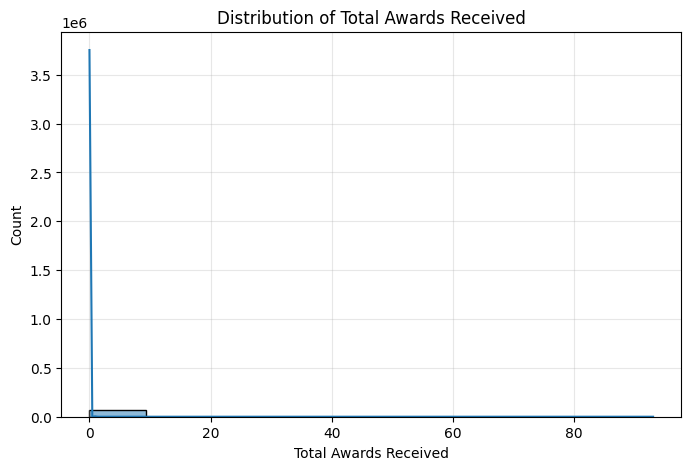

In [21]:
# Remove NaN or invalid values just in case
df['total_awards_received'] = pd.to_numeric(df['total_awards_received'], errors='coerce')
df_clean = df.dropna(subset=['total_awards_received'])

plt.figure(figsize=(8,5))
sns.histplot(df_clean['total_awards_received'], bins=10, kde=True)
plt.title('Distribution of Total Awards Received')
plt.xlabel('Total Awards Received')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.show()

In [22]:
df.total_awards_received.fillna(0,inplace=True)

/tmp/ipykernel_13484/976138776.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.total_awards_received.fillna(0,inplace=True)


In [23]:
df.isnull().sum()

,0
id,0
title,0
score,0
author,0
author_flair_text,0
removed_by,0
total_awards_received,0
full_link,0
num_comments,0
over_18,0


In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert categorical to numeric if needed
df['over_18'] = df['over_18'].astype(int)
# df['is_deleted'] = df['removed_by'].notnull().astype(int)

# Select numeric columns for correlation
num_cols = ['score', 'num_comments', 'total_awards_received', 'over_18']
corr = df[num_cols].corr(method='pearson')
corr

,score,num_comments,total_awards_received,over_18
score,1.000000,0.574893,0.173429,0.015676
num_comments,0.574893,1.000000,0.116257,0.022924
total_awards_received,0.173429,0.116257,1.000000,0.001269
over_18,0.015676,0.022924,0.001269,1.000000


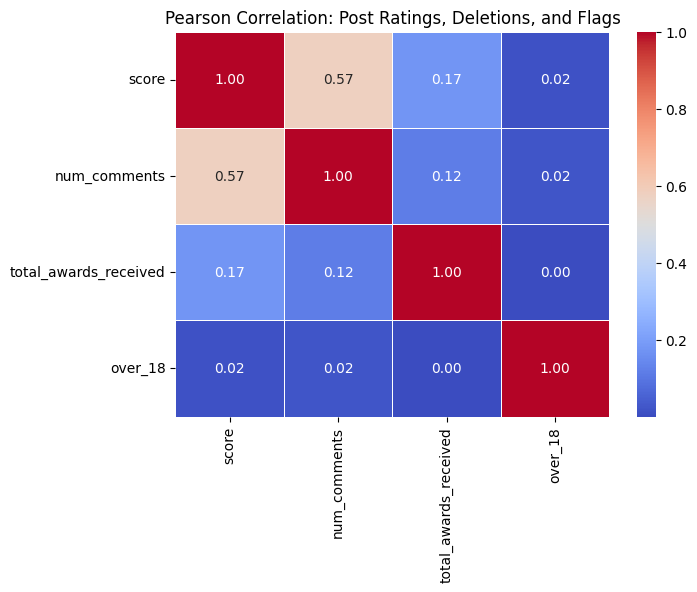

In [25]:
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation: Post Ratings, Deletions, and Flags")
plt.show()

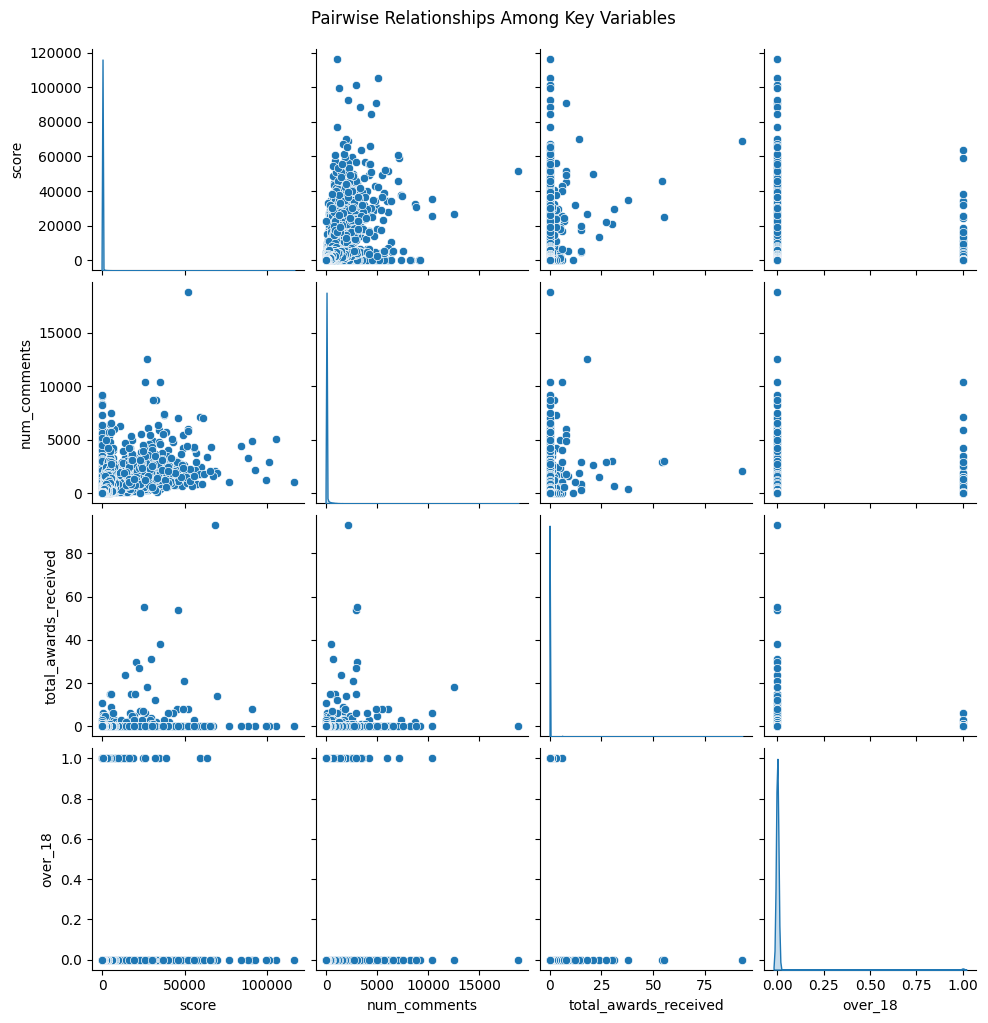

In [26]:
sns.pairplot(df[num_cols], diag_kind='kde')
plt.suptitle("Pairwise Relationships Among Key Variables", y=1.02)
plt.show()

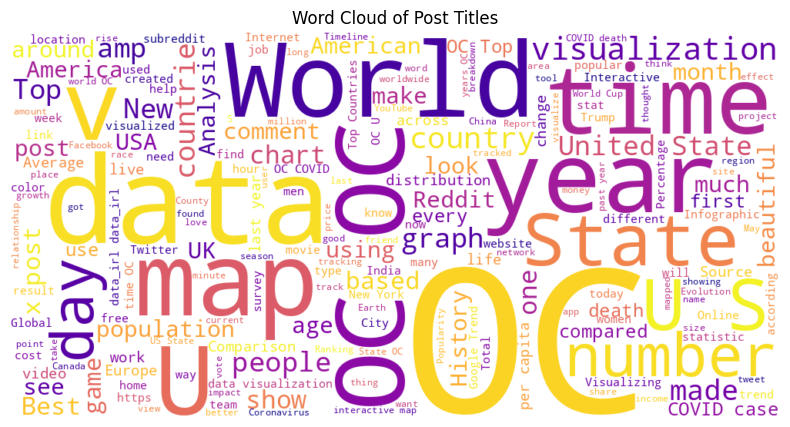

In [27]:
from wordcloud import WordCloud, STOPWORDS

text = " ".join(df['title'].dropna().astype(str))
wc = WordCloud(width=1000, height=500,
               background_color='white',
               stopwords=set(STOPWORDS),
               colormap='plasma').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Post Titles')
plt.show()

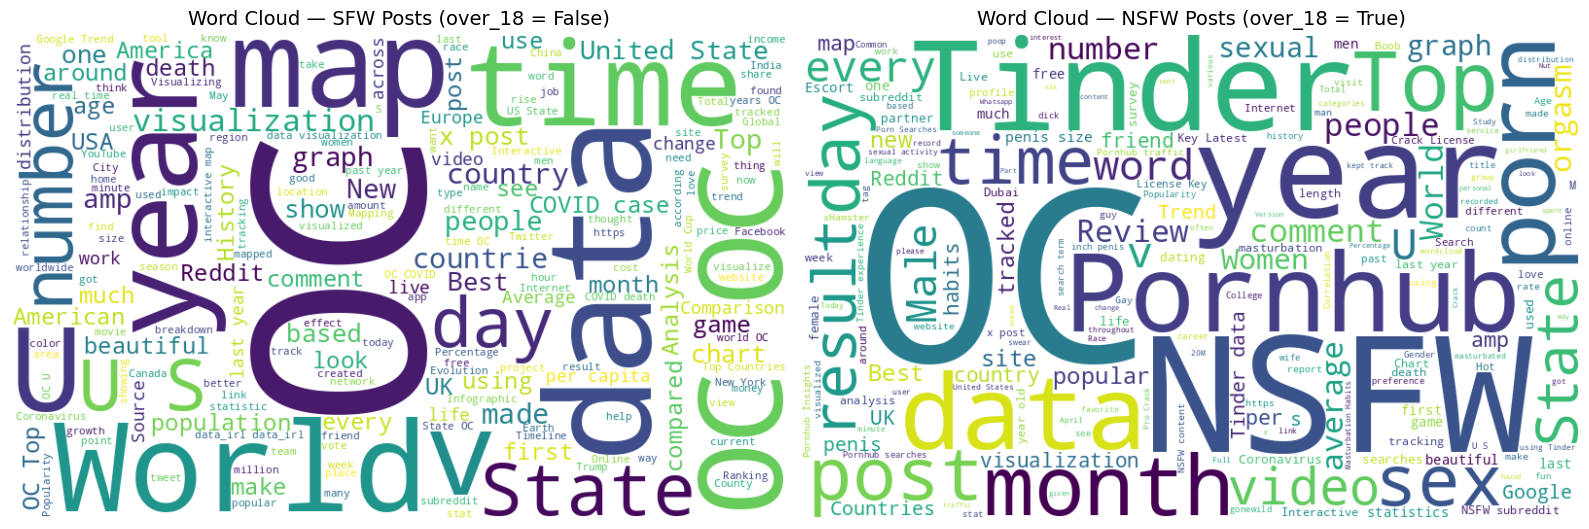

In [28]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Separate text for SFW and NSFW
sfw_text = " ".join(df[df['over_18'] == False]['title'].dropna().astype(str))
nsfw_text = " ".join(df[df['over_18'] == True]['title'].dropna().astype(str))

# Define common WordCloud settings
wc_params = {
    "width": 800,
    "height": 500,
    "background_color": "white",
    "stopwords": set(STOPWORDS),
    "colormap": "viridis"
}
# Generate both word clouds
wc_sfw = WordCloud(**wc_params).generate(sfw_text)
wc_nsfw = WordCloud(**wc_params).generate(nsfw_text)

# Plot side by side
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.imshow(wc_sfw, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — SFW Posts (over_18 = False)', fontsize=14)

plt.subplot(1, 2, 2)
plt.imshow(wc_nsfw, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — NSFW Posts (over_18 = True)', fontsize=14)

plt.tight_layout()
plt.show()


In [31]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [34]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

texts = df['title'].fillna("").astype(str)

texts = texts.apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x.lower()))

texts_tokenized = texts.apply(lambda x: x.split())

stop_words = set(stopwords.words('english')) | {"oc"}

texts_no_stop = texts_tokenized.apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

stemmer = PorterStemmer()

texts_stemmed = texts_no_stop.apply(
    lambda tokens: [stemmer.stem(word) for word in tokens]
)

texts_ready = texts_stemmed.apply(lambda tokens: " ".join(tokens))

texts_ready.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,title
0,wordcloud trend video titl youtub unit state
1,wordcloud trend video youtub unit state
2,immun india sourc httpsnitigovincontentimmunis
3,quickli estim impact player basketbal game
4,quickli estim impact player basketbal game


TF-IDF + train-test split


In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

tfidf = TfidfVectorizer(max_features=1000)

X_tfidf = tfidf.fit_transform(texts_ready)

y = df['over_18'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain set distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest set distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (152681, 1000)
X_test shape: (38171, 1000)

Train set distribution:
over_18
0    0.994407
1    0.005593
Name: proportion, dtype: float64

Test set distribution:
over_18
0    0.994394
1    0.005606
Name: proportion, dtype: float64


Decision Tree model

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

dt = DecisionTreeClassifier(
    max_depth=100,
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, zero_division=0)
rec_dt = recall_score(y_test, y_pred_dt, zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, zero_division=0)

print("Decision Tree Performance ")
print(f"Accuracy : {acc_dt:.2f}")
print(f"Precision: {prec_dt:.2f}")
print(f"Recall   : {rec_dt:.2f}")
print(f"F1-Score : {f1_dt:.2f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Performance 
Accuracy : 0.98
Precision: 0.09
Recall   : 0.32
F1-Score : 0.14

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     37957
           1       0.09      0.32      0.14       214

    accuracy                           0.98     38171
   macro avg       0.54      0.65      0.56     38171
weighted avg       0.99      0.98      0.98     38171



Random Forest model

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)

print("Random Forest Performance ")
print(f"Accuracy : {acc_rf:.2f}")
print(f"Precision: {prec_rf:.2f}")
print(f"Recall   : {rec_rf:.2f}")
print(f"F1-Score : {f1_rf:.2f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest Performance 
Accuracy : 0.99
Precision: 0.23
Recall   : 0.29
F1-Score : 0.25

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     37957
           1       0.23      0.29      0.25       214

    accuracy                           0.99     38171
   macro avg       0.61      0.64      0.62     38171
weighted avg       0.99      0.99      0.99     38171



Model comparison

In [41]:
print(" Model Comparison ")
print(f"Decision Tree Accuracy : {acc_dt:.2f}")
print(f"Decision Tree F1 Score : {f1_dt:.2f}")
print()
print(f"Random Forest Accuracy : {acc_rf:.2f}")
print(f"Random Forest F1 Score : {f1_rf:.2f}")

if f1_rf > f1_dt:
    print("\nRandom Forest performed better based on F1-score.")
elif f1_dt > f1_rf:
    print("\nDecision Tree performed better based on F1-score.")
else:
    print("\nBoth models performed equally based on F1-score.")

 Model Comparison 
Decision Tree Accuracy : 0.98
Decision Tree F1 Score : 0.14

Random Forest Accuracy : 0.99
Random Forest F1 Score : 0.25

Random Forest performed better based on F1-score.


In [42]:
import json

# Structured response schema
RESPONSE_SCHEMA = {
    "type": "object",
    "properties": {
        "nsfw_flag": {
            "type": "string",
            "enum": ["yes", "no"],
            "description": "Whether the Reddit post title is NSFW or sexually explicit."
        },
        "reason": {
            "type": "string",
            "description": "Short explanation for the classification."
        }
    },
    "required": ["nsfw_flag", "reason"]
}

# System prompt
SYSTEM_PROMPT = """
You are an AI content moderation assistant.

Your task is to determine whether a Reddit post title indicates NSFW (18+), sexually explicit, adult, or inappropriate content.

Rules:
1. Return only valid JSON.
2. The JSON must exactly follow this structure:
   {
     "nsfw_flag": "yes" or "no",
     "reason": "short explanation"
   }
3. Mark "yes" only if the title clearly suggests sexual, explicit adult, or NSFW content.
4. Mark "no" for safe, neutral, educational, analytical, or unrelated content.
5. Do not include markdown, code fences, or extra text outside JSON.
"""

# Function to create user prompt
def build_user_prompt(title: str) -> str:
    return f'Classify this Reddit post title: "{title}"'


# Example local fallback classifier
# (useful for testing without API call)
def simple_rule_based_nsfw_check(title: str) -> dict:
    nsfw_keywords = {
        "nsfw", "sex", "sexual", "nude", "naked", "porn", "adult",
        "explicit", "xxx", "erotic", "18+", "onlyfans"
    }

    title_lower = title.lower()

    found_keywords = [word for word in nsfw_keywords if word in title_lower]

    if found_keywords:
        return {
            "nsfw_flag": "yes",
            "reason": f"Title contains NSFW-related keyword(s): {', '.join(found_keywords)}"
        }
    else:
        return {
            "nsfw_flag": "no",
            "reason": "Title does not indicate sexually explicit or adult content."
        }

# Example usage
sample_titles = [
    "NSFW: explicit adult content warning",
    "Beautiful data visualization of global temperature change",
    "Top 10 erotic novels of the year",
    "Reddit post about income inequality"
]

for title in sample_titles:
    result = simple_rule_based_nsfw_check(title)
    print(f"Title: {title}")
    print(json.dumps(result, indent=2))
    print("-" * 50)

Title: NSFW: explicit adult content warning
{
  "nsfw_flag": "yes",
  "reason": "Title contains NSFW-related keyword(s): adult, explicit, nsfw"
}
--------------------------------------------------
Title: Beautiful data visualization of global temperature change
{
  "nsfw_flag": "no",
  "reason": "Title does not indicate sexually explicit or adult content."
}
--------------------------------------------------
Title: Top 10 erotic novels of the year
{
  "nsfw_flag": "yes",
  "reason": "Title contains NSFW-related keyword(s): erotic"
}
--------------------------------------------------
Title: Reddit post about income inequality
{
  "nsfw_flag": "no",
  "reason": "Title does not indicate sexually explicit or adult content."
}
--------------------------------------------------


In [43]:
!pip install -q google-generativeai

import google.generativeai as genai

genai.configure(api_key="YOUR_API_KEY")

model = genai.GenerativeModel("gemini-1.5-flash")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [44]:
import os
import google.generativeai as genai

# read API key from environment
api_key = os.getenv("GEMINI_API_KEY")

# configure Gemini
genai.configure(api_key=api_key)

# load model
model = genai.GenerativeModel("gemini-1.5-flash")

In [45]:
def call_model(title_text, config):

    response = model.generate_content(
        contents=title_text,
        generation_config=config
    )

    return response.text

In [46]:
import json

def process_title(title_text):

    config = {
        "response_mime_type": "application/json",
        "response_schema": RESPONSE_SCHEMA,
        "system_instruction": SYSTEM_PROMPT,
        "thinking_config": {"thinking_budget": 0}
    }

    try:
        raw_response = call_model(title_text, config)

        parsed = json.loads(raw_response)

        return parsed.get("nsfw_flag", "no")

    except Exception:
        return "no"

In [47]:
df_sample = df.iloc[:10,:].copy()
print(df_sample.head())
df_sample['nsfw_flag'] = df_sample['title'].apply(process_title)
print(df_sample[['title','nsfw_flag']].head())

       id                                              title  score  \
0  ll1p9h  Wordcloud of trending video titles on YouTube ...      1   
1  ll1o4h  Wordcloud of trending videos on YouTube in the...      1   
2  ll15gx  Immunization in India. Source: https://niti.go...      1   
3  ll0iup  How to quickly estimate the impact of players ...      1   
4  ll0g9a  How to quickly estimate the impact of players ...      1   

                 author author_flair_text        removed_by  \
0             OmarZiada             OC: 1       Not Removed   
1             OmarZiada             OC: 1         moderator   
2  Professional_Napper_                           moderator   
3              Viziball                    automod_filtered   
4              Viziball                           moderator   

   total_awards_received                                          full_link  \
0                    0.0  https://www.reddit.com/r/dataisbeautiful/comme...   
1                    0.0  https://ww

In [48]:
df_sample = df.iloc[:10,:].copy()

df_sample["nsfw_flag"] = df_sample["title"].apply(process_title)

print(df_sample[["title","nsfw_flag"]])

                                               title nsfw_flag
0  Wordcloud of trending video titles on YouTube ...        no
1  Wordcloud of trending videos on YouTube in the...        no
2  Immunization in India. Source: https://niti.go...        no
3  How to quickly estimate the impact of players ...        no
4  How to quickly estimate the impact of players ...        no
5  PhpStorm 2020.3.3 Crack Full Activation Code L...        no
6  3DMark 2.17.7137 Crack + Serial Key 2021 For [...        no
7  DaVinci Resolve Studio 17.0 Cracked Patch Lice...        no
8  Auslogics File Recovery 10 Crack + License Key...        no
9  [OC] Timeline of the Rise and Fall of $GME (st...        no


In [50]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

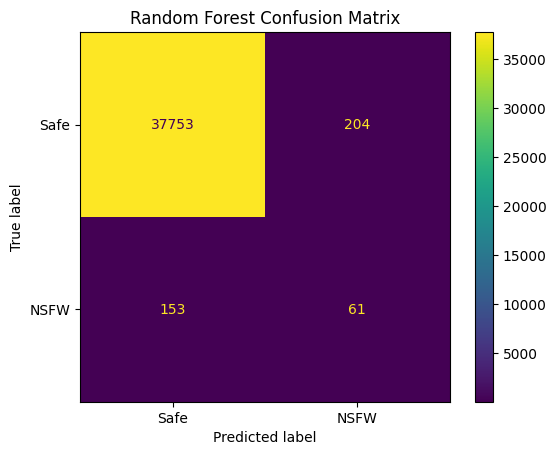

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Safe", "NSFW"],
    cmap="viridis"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [52]:
!git clone https://github.com/virtuoso1netizen/Reddit-Post-analysis.git

Cloning into 'Reddit-Post-analysis'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.
Resolving deltas: 100% (1/1), done.


In [53]:
%cd Reddit-Post-analysis

/content/Reddit-Post-analysis


In [54]:
!ls /content

r_dataisbeautiful_posts.csv  Reddit-Post-analysis  sample_data


In [55]:
%cd /content/Reddit-Post-analysis

/content/Reddit-Post-analysis


In [56]:
!ls

README.md


In [61]:
!find /content -name "*.ipynb"